In [36]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential, models
import matplotlib.pyplot as plt
import numpy as np

In [26]:
# 1. PARAMETERS & CONFIGURATION
img_height = 228
img_width = 228   # Fixed spelling from img_weight to avoid variable confusion
batch_size = 32   # Lowered from 128 to improve stability and gradient updates on small datasets
num_classes = 36
zip = zipfile.ZipFile("/content/drive/MyDrive/Fruits_Vegetables.zip")

In [27]:
zip.extractall("classdataset")

In [28]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
img_height = 228
img_weight = 228

In [29]:
data_dir = "/content/classdataset/Fruits_Vegetables/test"

In [30]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width), # FIXED: Dono 228 par match hain
    batch_size=batch_size,
    color_mode="rgb"
)

Found 359 files belonging to 36 classes.
Using 288 files for training.


In [31]:
# 20% Data Validation/Testing ke liye (Accuracy check karne ke liye)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb"
)

Found 359 files belonging to 36 classes.
Using 71 files for validation.


In [32]:
class_names = train_ds.class_names
print("\nTotal Classes Detected:", len(class_names))
print("Class Names:", class_names)


Total Classes Detected: 36
Class Names: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [33]:
# Memory pipeline optimization (Training fast karne ke liye)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [34]:
# Jab images kam hon, to yeh images ko rotate aur zoom karke network ko overfitting se bachata hai
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

In [38]:
model = models.Sequential([
    # Input Layer
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [40]:
model.compile(
    optimizer="adam",                        # Adam optimizer categorical data par base performance deta hai
    loss="sparse_categorical_crossentropy",   # 🔥 FIXED: Pehle 'binary' tha, isliye loss minus me ja raha tha
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 228, 228, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 228, 228, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 114, 114, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 114, 114, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 57, 57, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 57, 57, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,450,884 (24.61 MB)

 Trainable params: 6,450,884 (24.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(train_dateset,epochs=5,batch_size=128)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 8s/step - accuracy: 0.0347 - loss: 4.5141
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 7s/step - accuracy: 0.0312 - loss: 3.5828
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.0382 - loss: 3.5598
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 7s/step - accuracy: 0.0312 - loss: 3.5217
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 8s/step - accuracy: 0.0382 - loss: 3.5520


In [41]:
epochs = 15 # Epochs thode badha diye hain taake loss proper zero ki taraf jaye
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)



Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.0312 - loss: 4.0176 - val_accuracy: 0.0282 - val_loss: 3.5838
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.0451 - loss: 3.5709 - val_accuracy: 0.0282 - val_loss: 3.5527
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.0556 - loss: 3.4770 - val_accuracy: 0.0282 - val_loss: 3.4895
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.1146 - loss: 3.2799 - val_accuracy: 0.0282 - val_loss: 3.5228
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.1979 - loss: 3.0056 - val_accuracy: 0.0845 - val_loss: 3.4111
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.3090 - loss: 2.5372 - val_accuracy: 0.1268 - val_loss: 3.3892
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4479 - loss: 2.0613 - val_accuracy: 0.1127 - val_loss: 3.6098
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6111 - loss: 1.5713 - val_accuracy: 0.0845 - val_loss: 3.7653
Epoch 9/

In [42]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

Text(0.5, 1.0, 'Training and Validation Accuracy')

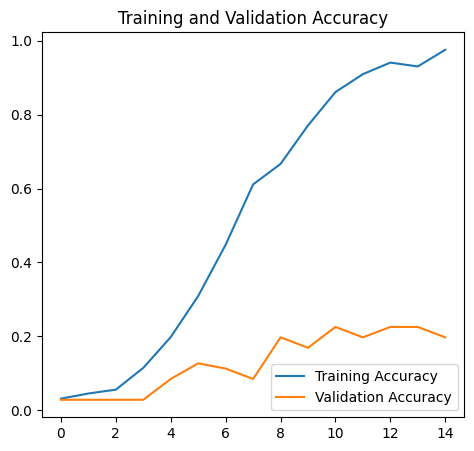

In [43]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')


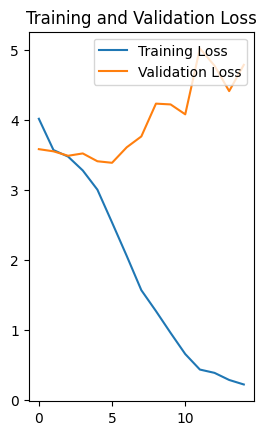

In [44]:
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [45]:
def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Model batch dimension create karne ke liye

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    print(f"\nPredicted Object: {class_names[np.argmax(score)]} with a {100 * np.max(score):.2f}% confidence.")


In [46]:
predict_image("/content/classdataset/Fruits_Vegetables/train/corn/Image_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step

Predicted Object: corn with a 6.65% confidence.


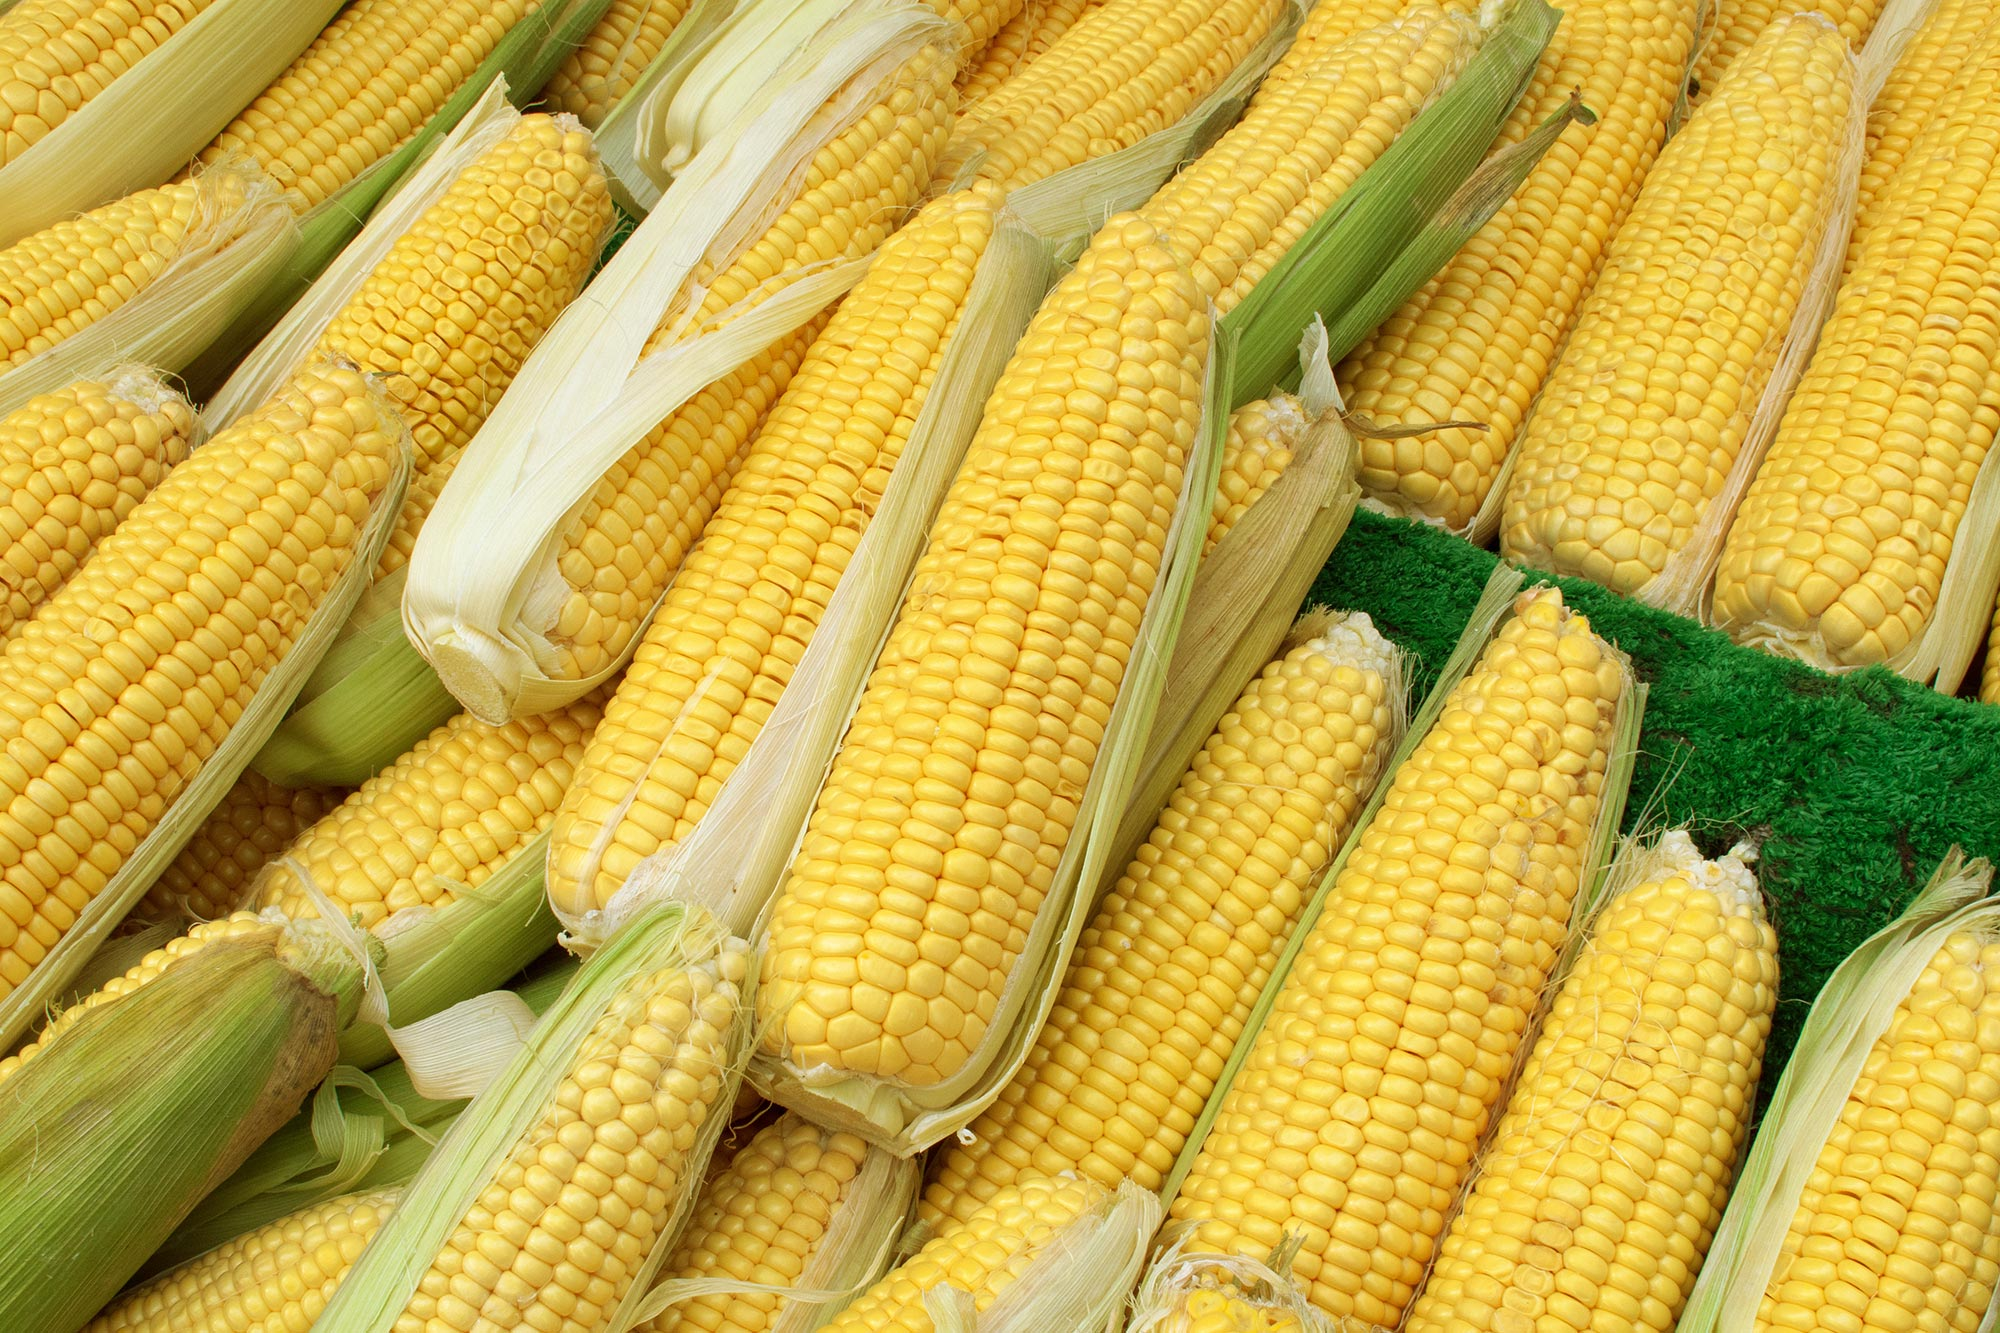

In [48]:
tf.keras.utils.load_img("/content/classdataset/Fruits_Vegetables/train/corn/Image_1.jpg")